## 1.2 Interpolation de Lagrange

### Base de Lagrange

On considère les polynômes $\varphi_k$, $k=0,\dots, n$ de
degré $n$ tels que

$$\varphi_k(x_j)=\delta_{jk}, \qquad k,j=0,\dots, n,$$

où $\delta_{jk}=1$ si $j=k$ et $\delta_{jk}=0$ si $j\neq k$.
Explicitement, on a

$$\varphi_k(x)=\prod_{j=0,j\ne k}^n\dfrac{(x-x_j)}{(x_k-x_j)}.$$

In [1]:
# importing libraries used in this book
import numpy as np
import matplotlib.pyplot as plt

**Exercice (théorique)** Vérifiez que

1. $B = \{\varphi_k, k=0,\dots, n\}$ est une base de $P_n(\mathbb R)$
2. Chaque polynôme $\varphi_k$ est de degré $n$
3. $\varphi_k(x_j)=\delta_{jk}, \qquad k,j=0,\dots, n$


In [4]:
# Defining the Lagrange basis functions
def phi(x,k,z):
    # the input variables are:
    # x : the interpolatory points
    # k : which basis function
    # z : where to evaluate the function
    

    # careful, there are n+1 interpolation points!
    n = x.size - 1 

    # init result to one, of same type and size as z
    result = np.zeros_like(z) + 1

    # first few checks on k:
    if (type(k) != int) or (x.size < 1) or (k > n) or (k < 0):
        raise ValueError('Lagrange basis needs a positive integer k, smaller than the size of x')
        
    # loop on n to compute the product
    for j in range(0,n+1) :
        if (j == k) :
            continue
        if (x[k] == x[j]) :
            raise ValueError('Lagrange basis: all the interpolation points need to be distinct')

        # >>> COMPLETE HERE <<<
        result = result * (z-x[j])/(x[k]-x[j])

    return result

#### Exemple

Pour $n=2$, $x_0=-1$, $x_1=0$, $x_2=1$, les polynômes de la base de Lagrange
sont

\begin{equation*}
\begin{array}{lcl}
\varphi_0(x)&=&\displaystyle\dfrac{(x-x_1)(x-x_2)}{(x_0-x_1)(x_0-x_2)}=
\dfrac{1}{2}x(x-1),\\[2mm]
\varphi_1(x)&=&\displaystyle\dfrac{(x-x_0)(x-x_2)}{(x_1-x_0)(x_1-x_2)}=
-(x+1)(x-1),\\[2mm]
\varphi_2(x)&=&\displaystyle\dfrac{(x-x_0)(x-x_1)}{(x_2-x_0)(x_2-x_1)}=
\dfrac{1}{2}x(x+1).
\end{array}
\end{equation*}


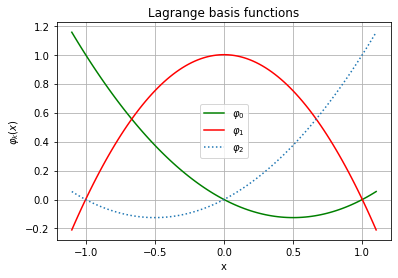

In [5]:
# plot the Lagrange Basis functions 
x = np.linspace(-1., 1, 3)
z = np.linspace(-1.1, 1.1, 100)

plt.plot(z, phi(x,0,z), 'g', z, phi(x,1,z), 'r', z, phi(x,2,z),':')

plt.xlabel('x'); plt.ylabel('$\\varphi_{k}(x)$'); plt.title('Lagrange basis functions')
plt.legend(['$\\varphi_{0}$','$\\varphi_{1}$','$\\varphi_{2}$'])
plt.grid(True)
plt.show()

#### Exercice

Visualisez la base de Lagrange associée aux points $x_k = 1, 1.5, 2, 2.5, 3$.
Evaluez sur le graphique les valeurs de $\varphi_k(x_j)$


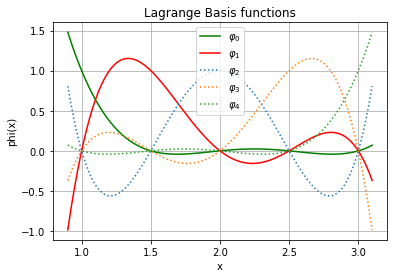

In [6]:
# plot the Lagrange Basis functions 
x = np.linspace(1., 3, 5)
z = np.linspace(0.9, 3.1, 100)

plt.plot(z, phi(x,0,z), 'g', z, phi(x,1,z), 'r', z, phi(x,2,z),':', z, phi(x,3,z),':', z, phi(x,4,z),':')

plt.xlabel('x'); plt.ylabel('phi(x)'); plt.title('Lagrange Basis functions')
plt.legend(['$\\varphi_0$','$\\varphi_1$','$\\varphi_2$',
            '$\\varphi_3$','$\\varphi_4$'])
plt.grid(True)
plt.show()

### Polynôme d'interpolation

Le polynôme d'interpolation $\Pi_n$ des
valeurs $y_j$ aux noeuds $x_j$, $j=0,\dots,n$, s'écrit
  $$
  \Pi_n(x)=\sum_{k=0}^n y_k \varphi_k(x),
  $$
car il vérifie $\Pi_n(x_j)=\sum_{k=0}^n y_k \varphi_k(x_j)=y_j$.

